- Получите данные и загрузите их в рабочую среду.
https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
- Подготовьте датасет к обучению моделей.

a) Категориальные переменные переведите в цифровые значения. Можно использовать pd.get_dummies, preprocessing.LabelEncoder. Старайтесь не использовать для этой задачи циклы.

b) *Постройте 1-2 графика на выбор. Визуализация должна быть основана на исследуемых данных и быть полезной (из графика можно сделать вывод об особенностях датасета/класса/признака).
- Разделите выборку на обучающее и тестовое подмножество. 80% данных оставить на обучающее множество, 20% на тестовое.
- Обучите дерево решений на обучающем множестве. Используйте следующие модели:
a) tree.DecisionTreeClassifier
b) ensemble.RandomForestClassifier
- Для тестового множества сделайте предсказание целевой переменной. Выведите метрики для каждой построенной модели с помощью metrics.classification_report.
- Выведите важность признаков, полученную после обучения модели RandomForestClassifier в виде столбчатой диаграммы. Отсортируйте важность по убыванию.
- Обучите бэггинг над моделью DecisionTreeClassifier. Используйте ensemble.BaggingClassifier.
- Повторите metrics.classification_report.
- Обучите стекинг 3 моделей: DecisionTreeClassifier, RandomForestClassifier и svm.LinearSVC. Используйте ensemble.StackingClassifier.
- Повторите metrics.classification_report.
- Сформулируйте выводы по проделанной работе.
a) Сравните метрики построенных моделей.
b) Напишите свое мнение, какая модель наилучшая и почему.
- Для получения зачета по этому домашнему заданию, минимально, должны быть обучены следующие модели: дерево решений, стекинг трех моделей. В данных должны быть обработаны категориальные значения.
Результат: получены знания по использованию базовых ансамблевых методов.

- https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html
- https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier
from sklearn.metrics import classification_report
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from lightgbm import LGBMClassifier
import seaborn as sns
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import accuracy_score

In [ ]:
#plt.rcParams['figure.figsize'] = (4, 4)

In [ ]:
df = pd.read_csv('heart.csv')
df.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


### ⚪ Третий вариант работы

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


<Axes: >

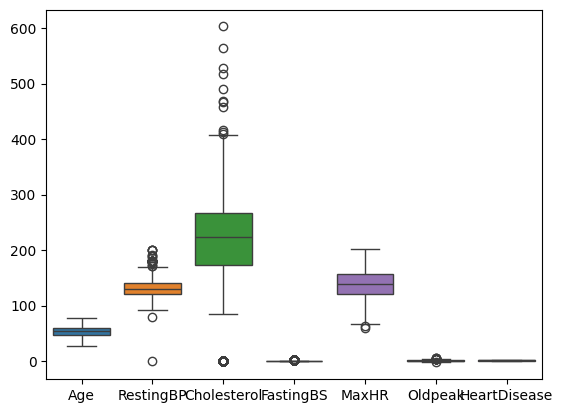

In [ ]:
sns.boxplot(df)

<Axes: ylabel='Cholesterol'>

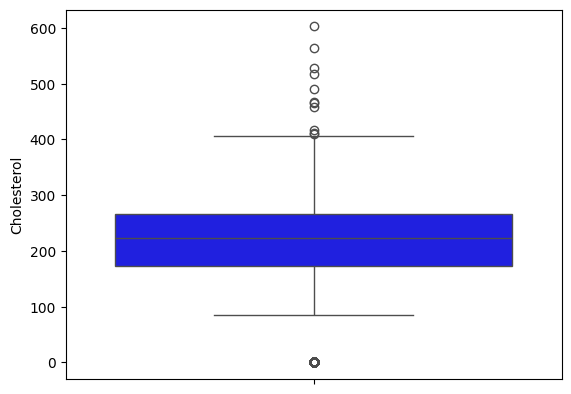

In [ ]:
#sns.boxplot(df[['RestingBP', 'Cholesterol', 'MaxHR',	'Oldpeak']])
sns.boxplot(df['Cholesterol'], color='blue')
# холестирин не может быть 0 никак

In [ ]:
df[df['Cholesterol'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1


In [ ]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
cat = df.select_dtypes('object')

In [ ]:
%%time
[(i, cat[i].nunique()) for i in cat.columns]

CPU times: user 2.06 ms, sys: 2 µs, total: 2.06 ms
Wall time: 1.87 ms


[('Sex', 2),
 ('ChestPainType', 4),
 ('RestingECG', 3),
 ('ExerciseAngina', 2),
 ('ST_Slope', 3)]

In [ ]:
for i in cat.columns:
  print(i, cat[i].value_counts(), '\n')

Sex Sex
M    725
F    193
Name: count, dtype: int64 

ChestPainType ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64 

RestingECG RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64 

ExerciseAngina ExerciseAngina
N    547
Y    371
Name: count, dtype: int64 

ST_Slope ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64 



In [ ]:
df['Sex'] = df['Sex'].map({'M':0, 'F': 1})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'N':0, 'Y': 1})
df['ChestPainType'] = df['ChestPainType'].map({'ASY':0, 'NAP':1, 'ATA':2, 'TA': 3})
df['RestingECG'] = df['RestingECG'].map({'Normal':0, 'LVH':1, 'ST': 2})
df['ST_Slope'] = df['ST_Slope'].map({'Flat':0, 'Up':1, 'Down': 2})

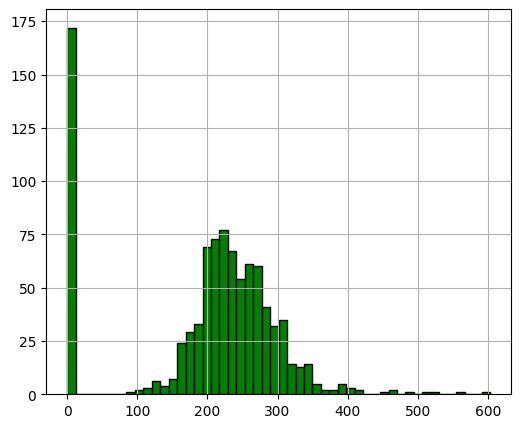

In [ ]:
plt.figure(figsize=(6,5))
plt.hist(df.Cholesterol, bins=50, color='g', edgecolor='k')
plt.grid()
plt.show()

In [ ]:
median_ = df[df['Cholesterol'] != 0]['Cholesterol'].median()
mean_ = df[df['Cholesterol'] != 0]['Cholesterol'].mean()
median_, mean_

(237.0, np.float64(244.6353887399464))

In [ ]:
# нужно убрать 0 значения, или это выбросы, или нет данных
df.loc[df['Cholesterol'] == 0, 'Cholesterol'] = df['Cholesterol'].replace(0, median_)

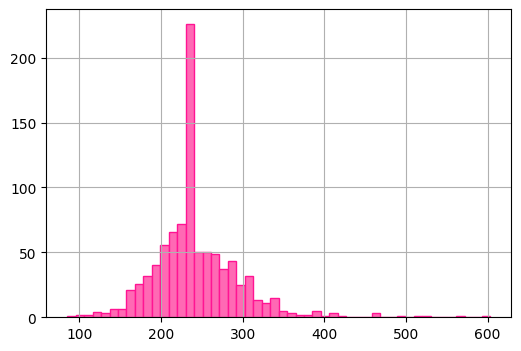

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df.Cholesterol, bins=50, color='hotpink', edgecolor='deeppink')
plt.grid()
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['HeartDisease']), df['HeartDisease'], test_size=.2, random_state=987)

In [ ]:
dec_tree = DecisionTreeClassifier(max_depth=15, min_samples_leaf=5, random_state=765).fit(x_train, y_train)
dec_tree.score(x_train, y_train), dec_tree.score(x_test, y_test)

(0.9128065395095368, 0.8206521739130435)

In [ ]:
y_pred = dec_tree.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1])

In [ ]:
target_names = ['class 0', 'class 1']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.80      0.81      0.81        85
     class 1       0.84      0.83      0.83        99

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



In [ ]:
ran_tree = RandomForestClassifier(max_depth=15, min_samples_leaf=5, oob_score=True, random_state=56765, n_jobs=-1).fit(x_train, y_train)
ran_tree.score(x_train, y_train), ran_tree.score(x_test, y_test)

(0.9100817438692098, 0.8858695652173914)

In [ ]:
ran_tree.oob_score_

0.8583106267029973

In [ ]:
y_pred = ran_tree.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1])

In [ ]:
target_names = ['class 0', 'class 1']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.89      0.86      0.87        85
     class 1       0.88      0.91      0.90        99

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



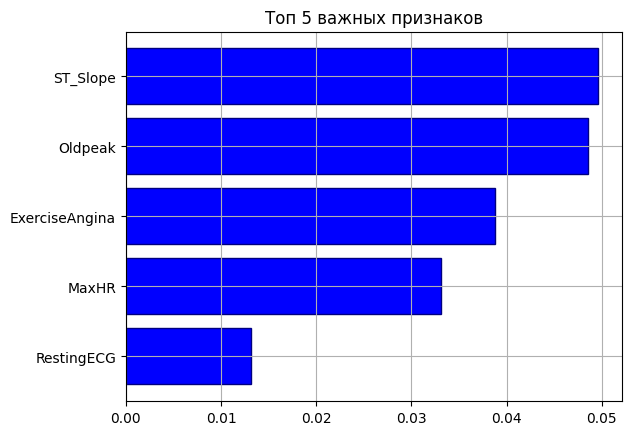

In [ ]:
cols = x_train[['ST_Slope', 'Oldpeak', 'ExerciseAngina', 'MaxHR', 'RestingECG']].columns[::-1]
features = sorted(ran_tree.feature_importances_)[:5]
plt.barh(cols, features, color='blue', edgecolor='navy')
plt.grid()
plt.title('Топ 5 важных признаков')
plt.show()

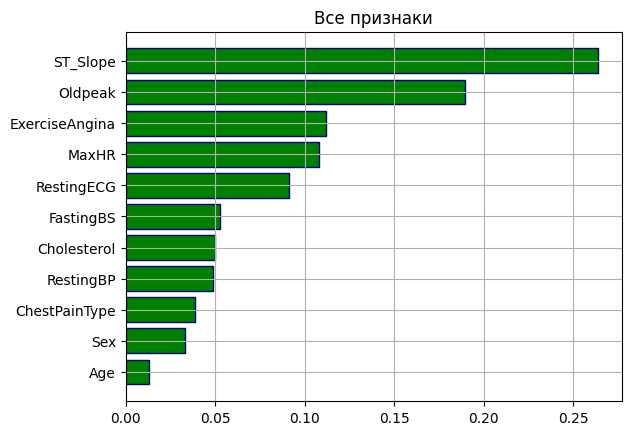

In [ ]:
plt.barh(x_train.columns, sorted(ran_tree.feature_importances_), color='g', edgecolor='navy')
plt.grid()
plt.title('Все признаки')
plt.show()

In [ ]:
dtree = DecisionTreeClassifier(max_depth=15, min_samples_leaf=5, random_state=765)

In [ ]:
bag = BaggingClassifier(dtree, n_estimators=100, oob_score=True, random_state=987).fit(x_train, y_train)

In [ ]:
bag.score(x_train, y_train), ran_tree.score(x_test, y_test), bag.oob_score_

(0.9223433242506812, 0.8858695652173914, 0.8419618528610354)

In [ ]:
y_pred = bag.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1])

In [ ]:
target_names = ['class 0', 'class 1']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.88      0.85      0.86        85
     class 1       0.87      0.90      0.89        99

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184



In [ ]:
est = [('rand', RandomForestClassifier(max_depth=15, min_samples_leaf=5, random_state=1)),
       ('dec', DecisionTreeClassifier(max_depth=15, min_samples_leaf=5, random_state=2)),
       ('svc', LinearSVC(random_state=3))]

stack = StackingClassifier(est, n_jobs=-1).fit(x_train, y_train)

In [ ]:
stack.score(x_train, y_train), stack.score(x_test, y_test)

(0.9100817438692098, 0.8804347826086957)

In [ ]:
y_pred = stack.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1])

In [ ]:
target_names = ['class 0', 'class 1']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.89      0.85      0.87        85
     class 1       0.87      0.91      0.89        99

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



### ⚪ Второй вариант работы

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [ ]:
df.ChestPainType.value_counts()

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


In [ ]:
df.RestingECG.value_counts()

,count
RestingECG,
Normal,552
LVH,188
ST,178


In [ ]:
df.ExerciseAngina.value_counts()

,count
ExerciseAngina,
N,547
Y,371


In [ ]:
df.ST_Slope.value_counts()

,count
ST_Slope,
Flat,460
Up,395
Down,63


In [ ]:
label = LabelEncoder()

In [ ]:
df['Sex'] = label.fit_transform(df['Sex'])
df['ExerciseAngina'] = label.fit_transform(df['ExerciseAngina'])

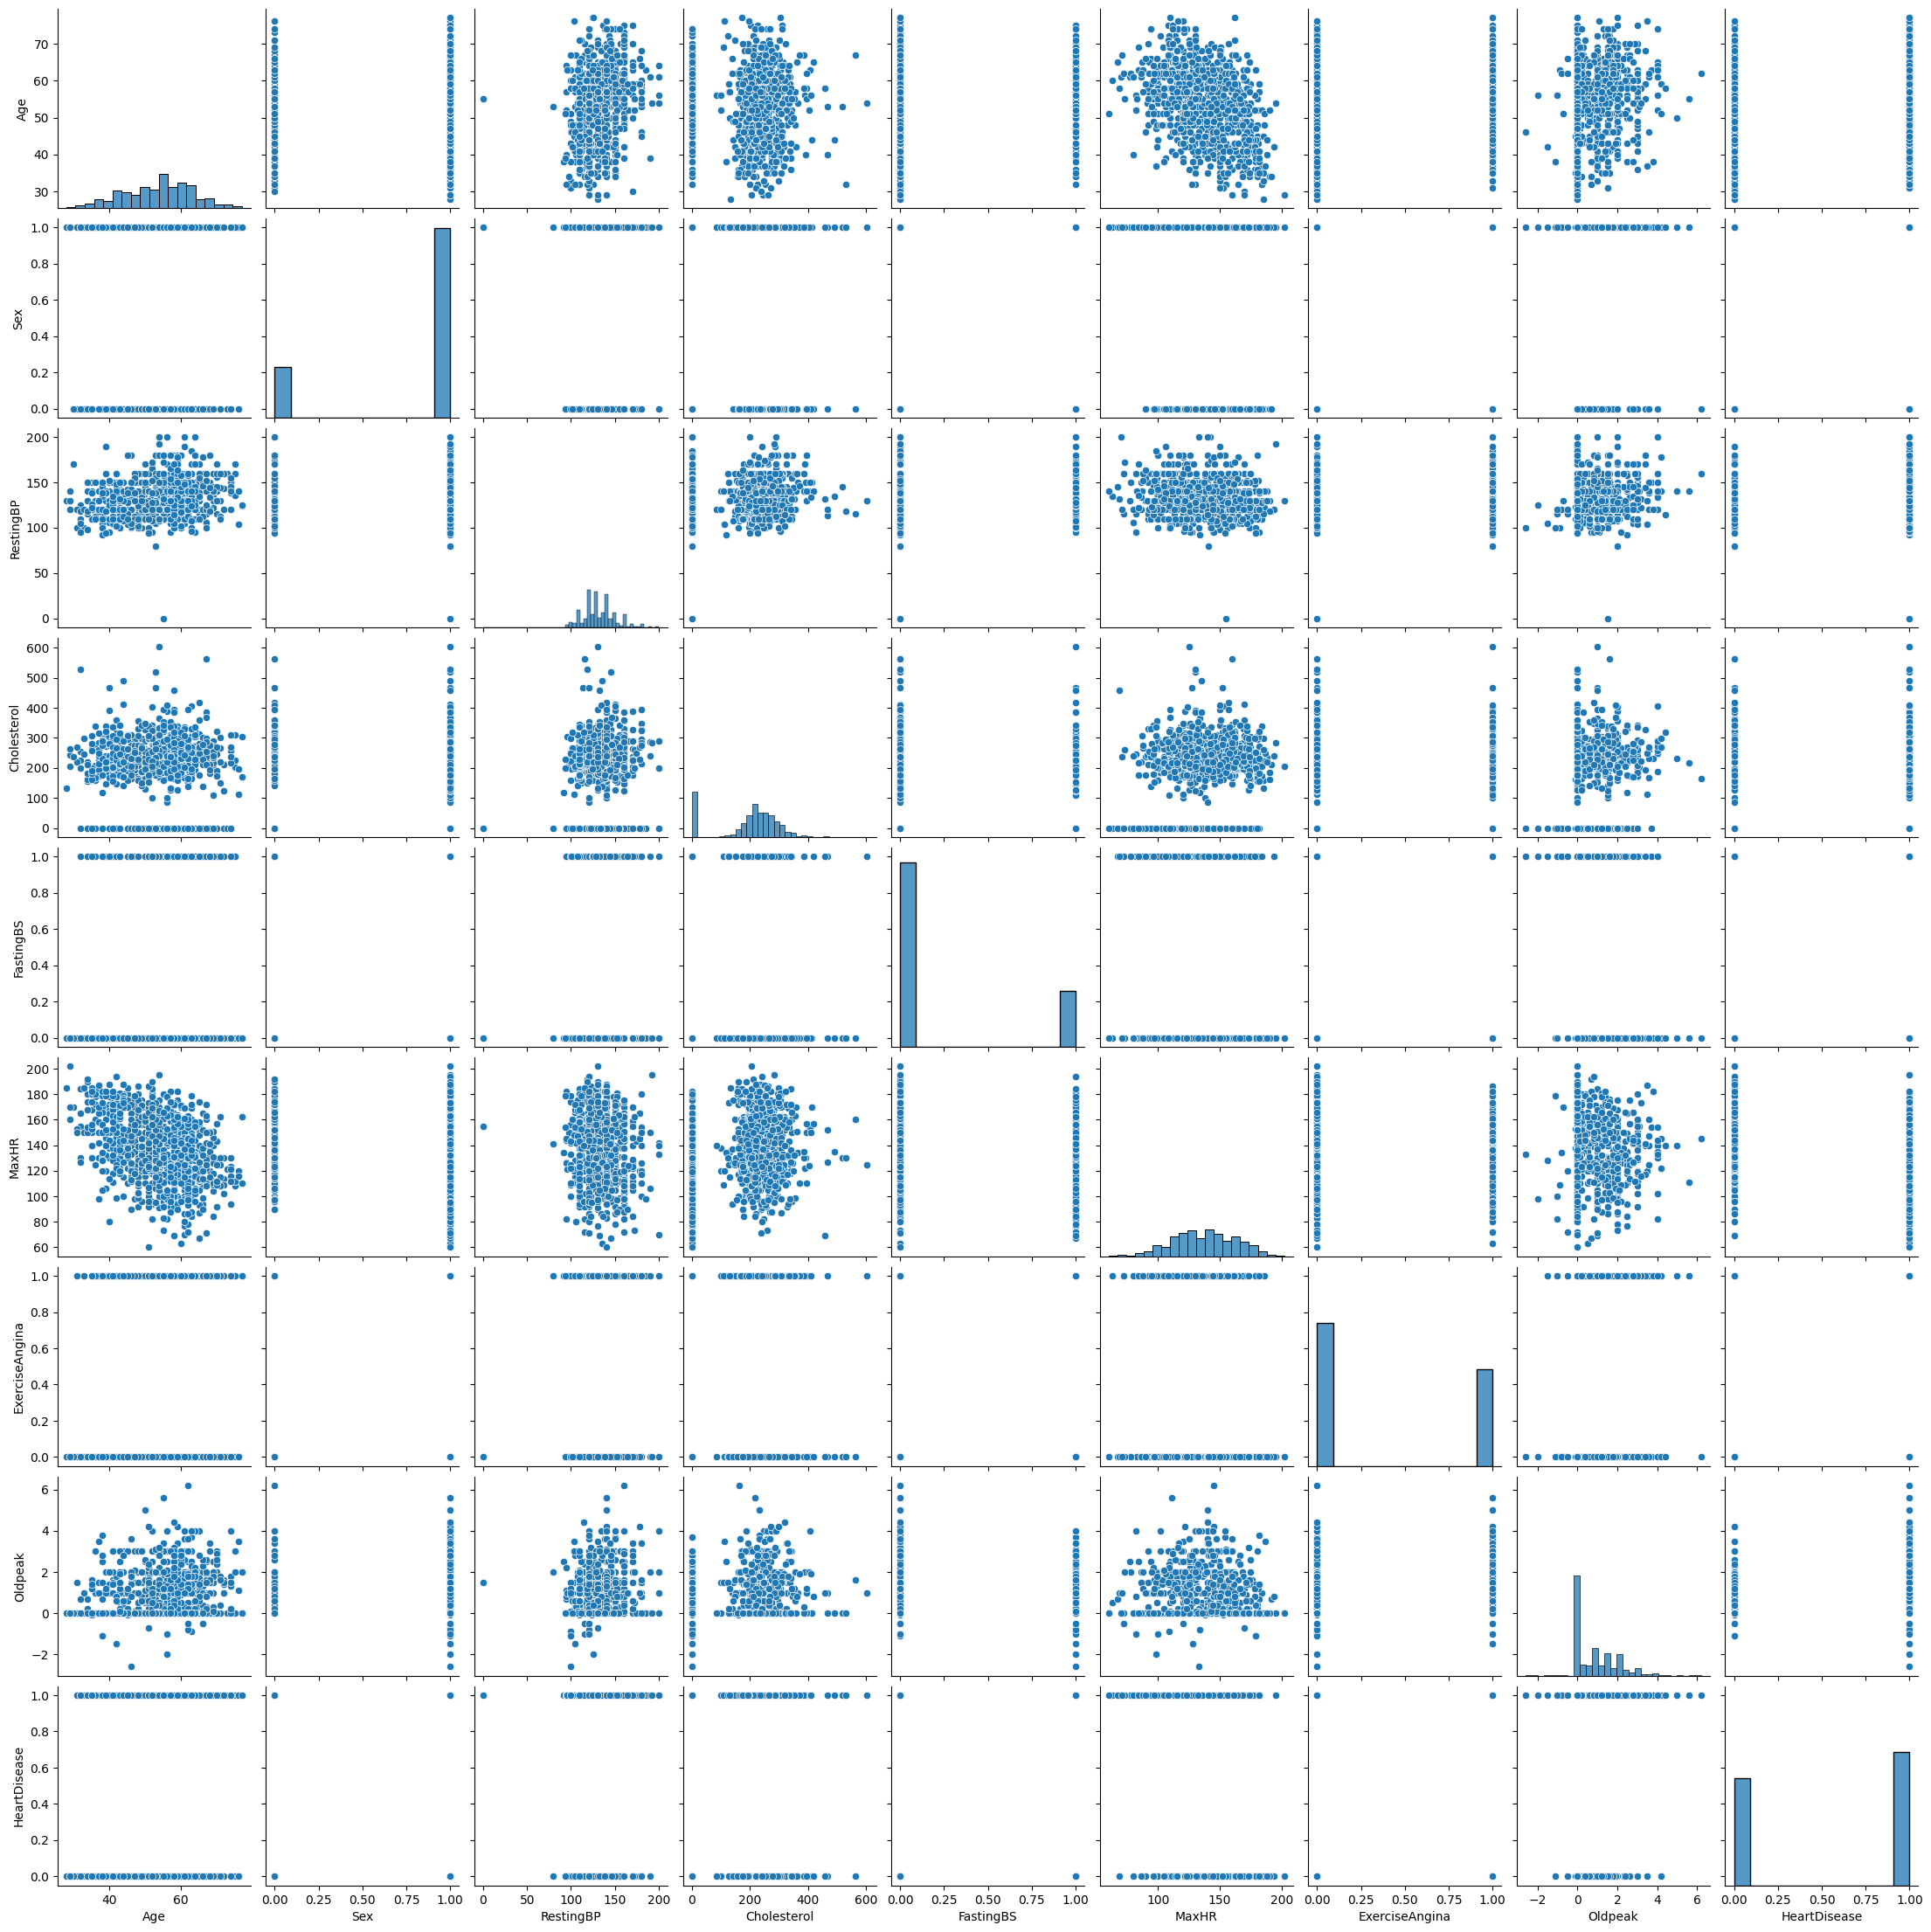

In [ ]:
sns.pairplot(df)

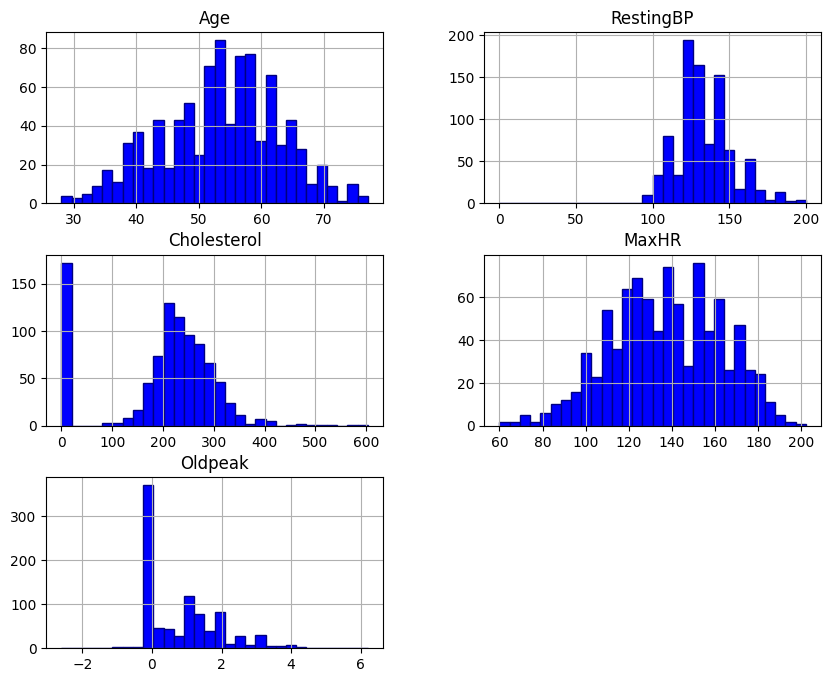

In [ ]:
df[['Age', 'ChestPainType', 'RestingBP', 'Cholesterol', 'RestingECG', 'MaxHR', 'Oldpeak', 'ST_Slope']].hist(color='b',
                                                                                bins=30, figsize=(10,8), edgecolor='navy')
plt.grid()
plt.show()

In [ ]:
df = pd.get_dummies(df)

In [ ]:
df.sample(4)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
194,41,0,125,184,0,180,0,0.0,0,False,True,False,False,False,True,False,False,False,True
844,52,1,118,186,0,190,0,0.0,0,False,False,False,True,True,False,False,False,True,False
215,30,0,170,237,0,170,0,0.0,0,False,False,False,True,False,False,True,False,False,True
856,39,1,140,321,0,182,0,0.0,0,False,False,True,False,True,False,False,False,False,True


In [ ]:
y = df['HeartDisease']

In [ ]:
del df['HeartDisease']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=0)

In [ ]:
dec_tree = DecisionTreeClassifier(random_state=0)

In [ ]:
dec_tree.fit(x_train,y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
pred_dec = dec_tree.predict(x_test)

In [ ]:
res_tree = round(accuracy_score(y_test, pred_dec),3)
res_tree

0.739

In [ ]:
res_dec = classification_report(y_test, pred_dec)
print(res_dec)

              precision    recall  f1-score   support

           0       0.66      0.79      0.72        77
           1       0.82      0.70      0.76       107

    accuracy                           0.74       184
   macro avg       0.74      0.75      0.74       184
weighted avg       0.75      0.74      0.74       184



oob_score=True (если bootstrap=True, по умолчанию) - использовать около 37% неиспользованных наблюдений в бутстреп-выборке для оценки работы алгоритма во время обучения, потому нет необходимости в кросс-валидации.

In [ ]:
ran_forest = RandomForestClassifier(oob_score=True, random_state=10)

In [ ]:
ran_forest.fit(x_train,y_train)

RandomForestClassifier(oob_score=True, random_state=10)

In [ ]:
ran_forest.oob_score_

0.8651226158038147

In [ ]:
pred_ran = ran_forest.predict(x_test)

In [ ]:
res_random = round(accuracy_score(y_test, pred_ran),3)
res_random

0.853

In [ ]:
res_ran = classification_report(y_test, pred_ran)
print(res_ran)

              precision    recall  f1-score   support

           0       0.86      0.78      0.82        77
           1       0.85      0.91      0.88       107

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



In [ ]:
ran_forest.feature_importances_

array([0.0756994 , 0.03359053, 0.06464691, 0.08976206, 0.02007355,
       0.09594959, 0.05576385, 0.10590057, 0.08523506, 0.02527349,
       0.01224857, 0.0066356 , 0.01285012, 0.00996288, 0.00820399,
       0.00887605, 0.11646439, 0.17286338])

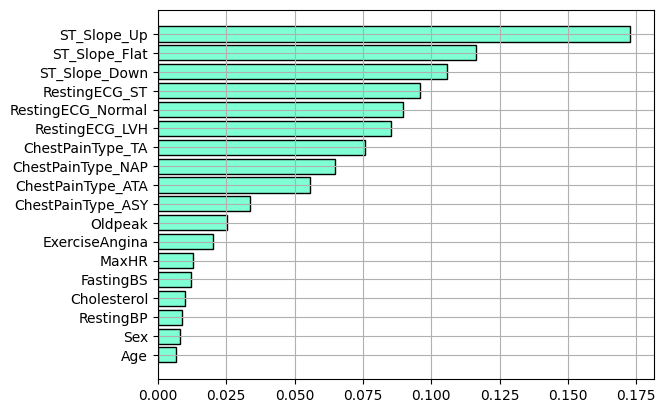

In [ ]:
plt.barh(x_train.columns, sorted(ran_forest.feature_importances_), color='aquamarine', edgecolor='k') # align='edge'
plt.grid()
plt.show()

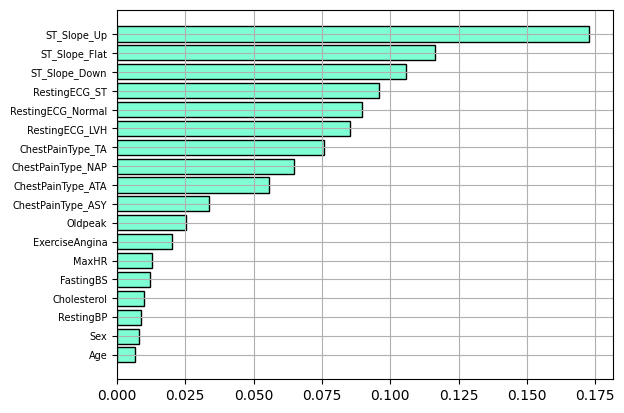

In [ ]:
plt.barh(np.arange(len(ran_forest.feature_importances_)), sorted(ran_forest.feature_importances_), color='aquamarine', edgecolor='k') # align='edge'
plt.yticks(np.arange(len(x_train.columns)), x_train.columns, fontsize=7)
plt.grid()
plt.show()

In [ ]:
bagg = BaggingClassifier(DecisionTreeClassifier(), n_estimators=30, random_state=0)

In [ ]:
bagg.fit(x_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=30,
                  random_state=0)

In [ ]:
pred_bagg = bagg.predict(x_test)

In [ ]:
res_bag = round(accuracy_score(y_test, pred_bagg),3)
res_bag

0.853

In [ ]:
res_bagg = classification_report(y_test, pred_bagg)
print(res_bagg)

              precision    recall  f1-score   support

           0       0.83      0.82      0.82        77
           1       0.87      0.88      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



In [ ]:
stackRidge = StackingClassifier([('DecisionTreeClassifier', DecisionTreeClassifier()),
                            ('RandomForestClassifier', RandomForestClassifier()),
                            ('LinearSVC', LinearSVC())],
                           RidgeClassifierCV())

In [ ]:
stackRidge.fit(x_train,y_train)

StackingClassifier(estimators=[('DecisionTreeClassifier',
                                DecisionTreeClassifier()),
                               ('RandomForestClassifier',
                                RandomForestClassifier()),
                               ('LinearSVC', LinearSVC())],
                   final_estimator=RidgeClassifierCV())

In [ ]:
pred_stack = stackRidge.predict(x_test)

In [ ]:
res_st = round(accuracy_score(y_test, pred_stack),3)
res_st

0.864

In [ ]:
res_stack = classification_report(y_test, pred_stack)
print(res_stack)

              precision    recall  f1-score   support

           0       0.87      0.79      0.83        77
           1       0.86      0.92      0.89       107

    accuracy                           0.86       184
   macro avg       0.87      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



In [ ]:
stackLogistic = StackingClassifier([('DecisionTreeClassifier', DecisionTreeClassifier()),
                            ('RandomForestClassifier', RandomForestClassifier()),
                            ('LinearSVC', LinearSVC())],
                            LogisticRegression())

In [ ]:
stackLogistic.fit(x_train,y_train)

StackingClassifier(estimators=[('DecisionTreeClassifier',
                                DecisionTreeClassifier()),
                               ('RandomForestClassifier',
                                RandomForestClassifier()),
                               ('LinearSVC', LinearSVC())],
                   final_estimator=LogisticRegression())

In [ ]:
pred_stackL = stackLogistic.predict(x_test)

In [ ]:
res_stL = round(accuracy_score(y_test, pred_stackL),3)
res_stL

0.853

In [ ]:
res_stackL = classification_report(y_test, pred_stackL)
print(res_stackL)

              precision    recall  f1-score   support

           0       0.87      0.77      0.81        77
           1       0.84      0.92      0.88       107

    accuracy                           0.85       184
   macro avg       0.86      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



In [ ]:
result = pd.DataFrame(data=[res_tree, res_random, res_bag, res_st, res_stL], columns = ['Accuracy'],
                      index = ['DecisionTree', 'RandomForest', 'Bagging', 'StackingRidgeClass', 'StackingLogistic'])

In [ ]:
result

,Accuracy
DecisionTree,0.739
RandomForest,0.853
Bagging,0.853
StackingRidgeClass,0.864
StackingLogistic,0.853


In [ ]:
"""
Вывод
Сравнивая два варианта работы, делаю вывод, что обработка данных перед обучением может повлиять на результат.
Плюс влияет выбор классификатора.
"""

### ⚪ Первый вариант работы

In [ ]:
data = pd.read_csv('heart.csv')
data.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


In [ ]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [ ]:
label = LabelEncoder()
label.fit(data['Sex'])
data['Sex'] = label.transform(data['Sex'])
data.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,N,0.0,Up,0


In [ ]:
lab = LabelEncoder()
lab.fit(data['ExerciseAngina'])
data['ExerciseAngina'] = lab.transform(data['ExerciseAngina'])
data.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0


In [ ]:
data = pd.get_dummies(data)

In [ ]:
data.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,False,True,False,False,False,True,False,False,False,True
1,49,0,160,180,0,156,0,1.0,1,False,False,True,False,False,True,False,False,True,False
2,37,1,130,283,0,98,0,0.0,0,False,True,False,False,False,False,True,False,False,True
3,48,0,138,214,0,108,1,1.5,1,True,False,False,False,False,True,False,False,True,False
4,54,1,150,195,0,122,0,0.0,0,False,False,True,False,False,True,False,False,False,True


<Figure size 640x480 with 0 Axes>

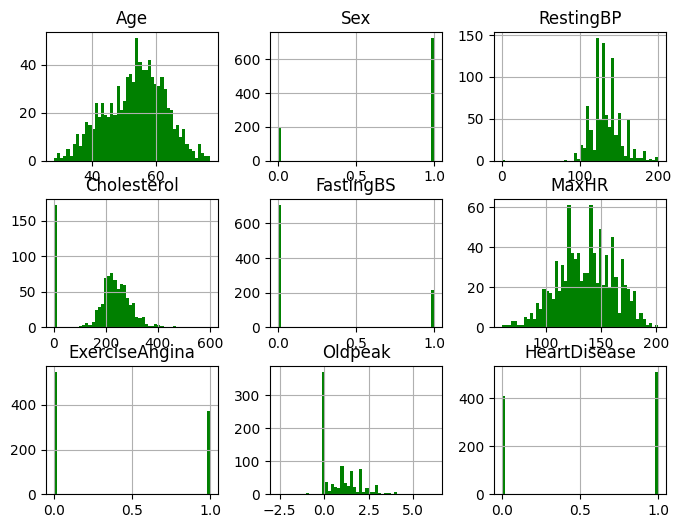

In [ ]:
plt.tight_layout()
data.hist(bins=50, figsize=(8,6), color='g')
plt.show()

In [ ]:
y = data['HeartDisease']
y.value_counts()

,count
HeartDisease,
1,508
0,410


In [ ]:
x = data.drop(columns='HeartDisease')

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=7)
x_train.shape, x_test.shape

((734, 18), (184, 18))

In [ ]:
tree_class = DecisionTreeClassifier(random_state=7)
tree_class.fit(x_train, y_train)
pred = tree_class.predict(x_test)

In [ ]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.76      0.78      0.77        90
           1       0.78      0.77      0.77        94

    accuracy                           0.77       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.77      0.77      0.77       184



In [ ]:
random_for = RandomForestClassifier(random_state=7)
random_for.fit(x_train, y_train)
preds = random_for.predict(x_test)

In [ ]:
print(classification_report(y_test, preds)) # случайный лес отработал лучше, чем деревья

              precision    recall  f1-score   support

           0       0.92      0.84      0.88        90
           1       0.86      0.93      0.89        94

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.89       184
weighted avg       0.89      0.89      0.89       184



In [ ]:
importance = pd.Series(random_for.feature_importances_).sort_values(ascending=False)
importance.index = pd.Series(x_train.columns)
importance

,0
Age,0.128069
Sex,0.107417
RestingBP,0.102134
Cholesterol,0.100646
FastingBS,0.097270
MaxHR,0.096936
ExerciseAngina,0.071751
Oldpeak,0.071106
ChestPainType_ASY,0.070757
ChestPainType_ATA,0.038035


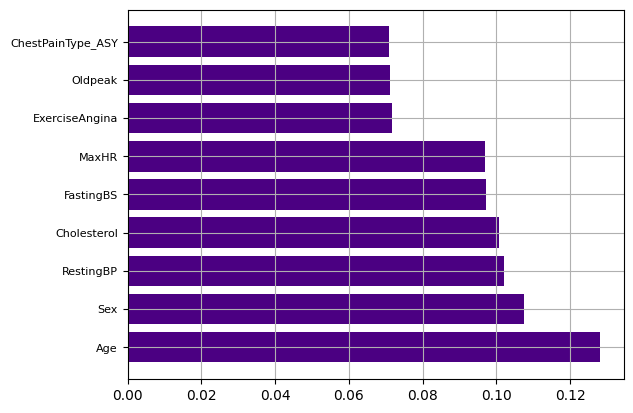

In [ ]:
plt.barh(importance.head(9).index, importance.head(9), color = 'indigo')
plt.yticks(fontsize=8)
plt.grid()
plt.show()

In [ ]:
bagging = BaggingClassifier(DecisionTreeClassifier(), random_state=7)
bagging.fit(x_train, y_train)
predict = bagging.predict(x_test)

In [ ]:
print(classification_report(y_test, predict)) # bagging ухудшил результат

              precision    recall  f1-score   support

           0       0.84      0.87      0.85        90
           1       0.87      0.84      0.85        94

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



In [ ]:
estimators = [('rfc', RandomForestClassifier(random_state=7)),
              ('dtc', DecisionTreeClassifier(random_state=7)),
              ('svr', make_pipeline(StandardScaler(), LinearSVC(max_iter=5000, random_state=7)))]

In [ ]:
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(x_train, y_train)

StackingClassifier(estimators=[('rfc', RandomForestClassifier(random_state=7)),
                               ('dtc', DecisionTreeClassifier(random_state=7)),
                               ('svr',
                                Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('linearsvc',
                                                 LinearSVC(max_iter=5000,
                                                           random_state=7))]))],
                   final_estimator=LogisticRegression())

In [ ]:
pre = stack.predict(x_test)               # тоже самое, что и у случайного леса
print(classification_report(y_test, pre))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89        90
           1       0.87      0.93      0.90        94

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



In [ ]:
lgbm = LGBMClassifier(random_state=7)
lgbm.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 414, number of negative: 320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000420 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.564033 -> initscore=0.257545
[LightGBM] [Info] Start training from score 0.257545
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

LGBMClassifier(random_state=7)

In [ ]:
pre_ = lgbm.predict(x_test) # немного хуже, чем у стэкинга и случайного леса
print(classification_report(y_test, pre_))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        90
           1       0.84      0.91      0.88        94

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

